In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

import warnings

In [4]:
def evaluate_model(true, predicted, model, X_test):
    precision = precision_score(true, predicted , zero_division = 0)
    recall = recall_score(true, predicted , zero_division = 0)
    f1 = f1_score(true , predicted, zero_division = 0)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(true, y_pred_proba)
    pr_auc = average_precision_score(true, y_pred_proba)
    return precision, recall, f1, roc_auc, pr_auc

In [5]:
scaled_X_train=pd.read_csv('model_data/scaled_blunder_blitz_X_train.csv')
y_train=pd.read_csv('model_data/blunder_blitz_y_train.csv')

In [6]:
scaled_X_test=pd.read_csv('model_data/scaled_blunder_blitz_X_test.csv')
y_test=pd.read_csv('model_data/blunder_blitz_y_test.csv')

In [7]:
scaled_X_train.shape

(20898, 25)

In [8]:
scaled_X_test.shape

(5225, 25)

In [9]:
y_train_blunder = y_train['is_blunder']
y_test_blunder  = y_test['is_blunder']

ratio = (y_train_blunder == 0).sum() / (y_train_blunder == 1).sum()

models = { 
        "CatBoosting Classifier": CatBoostClassifier(
            scale_pos_weight=ratio,
            eval_metric='AUC',
            iterations=300,
            random_seed=42,
            verbose=False,
        )
}
# define empty list
model_list = []
r2_list =[]

# for every model in the list
for i in range(len(list(models))):
    # set model to model at index i
    model = list(models.values())[i]

    # Train model
    model.fit(scaled_X_train, y_train) 

    # Get predicted probabilities for the positive class
    y_pred_proba = model.predict_proba(scaled_X_test)[:, 1]

    # Make predictions
    y_train_pred = model.predict(scaled_X_train)
    accuracy_train = accuracy_score(y_train , y_train_pred)

    y_test_pred = model.predict(scaled_X_test)
    accuracy_test = accuracy_score(y_test , y_test_pred)

    model_train_precision, model_train_recall, model_train_f1, model_train_roc_auc, model_train_pr_auc = evaluate_model(y_train, y_train_pred, model, scaled_X_train)
    model_test_precision, model_test_recall, model_test_f1, model_test_roc_auc, model_test_pr_auc = evaluate_model(y_test, y_test_pred, model, scaled_X_test)

    print(list(models.keys())[i])

    # append each model to model_list
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Training Accuracy: {:.4f}".format(accuracy_train))
    print("- Precision: {:.4f}".format(model_train_precision))
    print("- Recall: {:.4f}".format(model_train_recall))
    print("- F1 Score: {:.4f}".format(model_train_f1))
    print("- ROC_AUC: {:.4f}".format(model_train_roc_auc))
    print("- PR_AUC: {:.4f}".format(model_train_pr_auc))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Testing Accuracy: {:.4f}".format(accuracy_test))
    print("- Precision: {:.4f}".format(model_test_precision))
    print("- Recall: {:.4f}".format(model_test_recall))
    print("- F1 Score: {:.4f}".format(model_test_f1))
    print("- ROC_AUC: {:.4f}".format(model_test_roc_auc))
    print("- PR_AUC: {:.4f}".format(model_test_pr_auc))

    print('='*35)
    print('\n')

    # Extract feature importances from Gradient Boosting Classifier
    importances = model.feature_importances_
    feature_names = scaled_X_train.columns
    feature_importances = pd.Series(importances, index=feature_names)

    # sort feature importances and names
    feature_importances_sorted = feature_importances.sort_values(ascending=False)
    feature_names_sorted = feature_importances_sorted.index

    print(feature_importances_sorted)

CatBoosting Classifier
Model performance for Training set
- Training Accuracy: 0.9684
- Precision: 0.5000
- Recall: 1.0000
- F1 Score: 0.6667
- ROC_AUC: 0.9987
- PR_AUC: 0.9452
----------------------------------
Model performance for Test set
- Testing Accuracy: 0.9472
- Precision: 0.3528
- Recall: 0.8061
- F1 Score: 0.4908
- ROC_AUC: 0.9714
- PR_AUC: 0.4720


eval_volatility_norm          49.009879
time_spent_ratio               6.414517
eval_unified                   6.041641
color_white                    5.729124
time_eval_volatility_int       4.061236
cumulative_time_pressure       4.013935
avg_time_spent_per_move        3.688247
complexity_material_norm       2.775323
time_left_sec                  2.566251
move_number_norm               2.425260
material_time_pressure_int     2.350792
is_mate_threat                 2.146432
late_endgame_int               2.113699
time_pressure_norm             1.481241
time_left_ratio_clipped        1.399660
is_rook_move                   0.6579

In [10]:
def iterative_feature_removal(X_train, y_train, X_test, y_test, feature_importance_sorted):
    
    # Initialize results list
    results = []
    
    # Get list of features from most to least important
    features_list = feature_importance_sorted.index.tolist() 
    
    # Start with all features
    current_features = features_list.copy()
    
    iteration = 0
    while len(current_features) > 0:
        print(f"\n{'='*50}")
        print(f"Iteration {iteration + 1}: Training with {len(current_features)} features")
        print(f"{'='*50}")
        
        # Select current features for training and testing
        X_train_subset = X_train[current_features]
        X_test_subset = X_test[current_features]
        
        # Train model
        model = CatBoostClassifier(
            scale_pos_weight=ratio,
            eval_metric='AUC',
            iterations=300,
            random_seed=42,
            verbose=False,
        )
        model.fit(X_train_subset, y_train)
        
        # Get predictions
        y_train_pred = model.predict(X_train_subset)
        y_test_pred = model.predict(X_test_subset)
        y_test_pred_proba = model.predict_proba(X_test_subset)[:, 1]
        
        # Calculate metrics for training set
        train_acc = accuracy_score(y_train, y_train_pred)
        train_precision, train_recall, train_f1, train_roc_auc, train_pr_auc = evaluate_model(
            y_train, y_train_pred, model, X_train_subset
        )
        
        # Calculate metrics for test set
        test_acc = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred, zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
        test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
        test_pr_auc = average_precision_score(y_test, y_test_pred_proba)
        
        # Store results
        results.append({
            'num_of_features': len(current_features),
            'training_acc': train_acc,
            'test_acc': test_acc,
            'precision': test_precision,
            'recall': test_recall,
            'f1': test_f1,
            'roc_auc': test_roc_auc,
            'pr_auc': test_pr_auc
        })
        
        # Print current results
        print(f"Training Accuracy: {train_acc:.4f}")
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Precision: {test_precision:.4f}")
        print(f"Recall: {test_recall:.4f}")
        print(f"F1 Score: {test_f1:.4f}")
        print(f"ROC AUC: {test_roc_auc:.4f}")
        print(f"PR AUC: {test_pr_auc:.4f}")
        
        # Remove 2 least important features for next iteration
        if len(current_features) > 2:
            current_features = current_features[:-2]  # Remove last 2 features
        elif len(current_features) == 2:
            current_features = current_features[:-2]  # Remove both remaining features
        else:
            current_features = []  # Remove the last feature
        
        iteration += 1
    
    # Create DataFrame from results
    results_df = pd.DataFrame(results)
    
    # Reorder columns
    results_df = results_df[['num_of_features', 'training_acc', 'test_acc', 
                             'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']]
    
    return results_df

In [11]:
results_df = iterative_feature_removal(scaled_X_train, y_train, scaled_X_test, y_test, feature_importances_sorted)

# Display results
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))


Iteration 1: Training with 25 features
Training Accuracy: 0.9671
Test Accuracy: 0.9433
Precision: 0.3391
Recall: 0.8364
F1 Score: 0.4825
ROC AUC: 0.9730
PR AUC: 0.4823

Iteration 2: Training with 23 features
Training Accuracy: 0.9686
Test Accuracy: 0.9447
Precision: 0.3402
Recall: 0.8000
F1 Score: 0.4774
ROC AUC: 0.9723
PR AUC: 0.4932

Iteration 3: Training with 21 features
Training Accuracy: 0.9682
Test Accuracy: 0.9468
Precision: 0.3509
Recall: 0.8061
F1 Score: 0.4890
ROC AUC: 0.9719
PR AUC: 0.4658

Iteration 4: Training with 19 features
Training Accuracy: 0.9672
Test Accuracy: 0.9443
Precision: 0.3401
Recall: 0.8121
F1 Score: 0.4794
ROC AUC: 0.9712
PR AUC: 0.4650

Iteration 5: Training with 17 features
Training Accuracy: 0.9684
Test Accuracy: 0.9453
Precision: 0.3420
Recall: 0.7939
F1 Score: 0.4781
ROC AUC: 0.9716
PR AUC: 0.4549

Iteration 6: Training with 15 features
Training Accuracy: 0.9672
Test Accuracy: 0.9453
Precision: 0.3453
Recall: 0.8182
F1 Score: 0.4856
ROC AUC: 0.9710
P

RECURSIVE FEATURE ELIMINATION WITH CROSS-VALIDATION (RFECV)

Fitting RFECV...
Starting with 25 features


Optimal number of features: 7
Features removed: 18

Selected features (7):
  1. time_left_sec
  2. time_spent_ratio
  3. eval_unified
  4. complexity_material_norm
  5. eval_volatility_norm
  6. time_eval_volatility_int
  7. color_white

Eliminated features (18):
  1. white_castled_king
  2. white_castled_queen
  3. black_castled_king
  4. black_castled_queen
  5. queen_present
  6. is_middlegame
  7. is_pawn_move
  8. is_bishop_move
  9. is_rook_move
  10. is_queen_move
  11. avg_time_spent_per_move
  12. is_mate_threat
  13. time_pressure_norm
  14. material_time_pressure_int
  15. move_number_norm
  16. late_endgame_int
  17. cumulative_time_pressure
  18. time_left_ratio_clipped

MODEL PERFORMANCE WITH SELECTED FEATURES

Number of Features: 7
Training Accuracy: 0.9611
Test Accuracy: 0.9432
Precision: 0.3413
Recall: 0.8606
F1 Score: 0.4888
ROC AUC: 0.9716
PR AUC: 0.4822


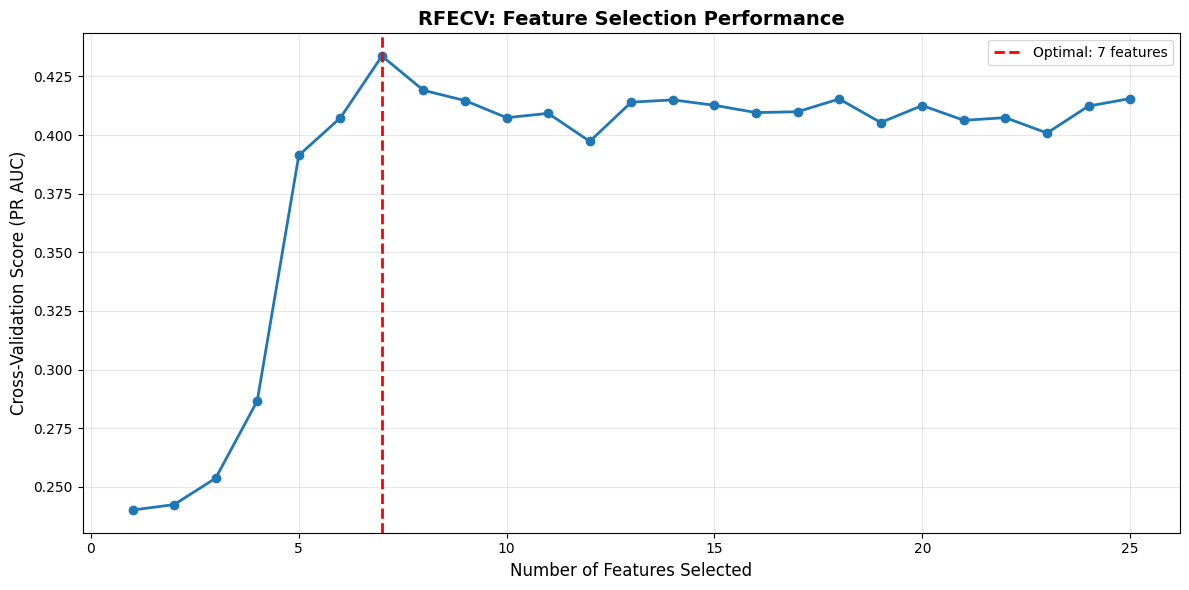


FEATURE RANKING
                   Feature  Ranking  Selected
             time_left_sec        1      True
          time_spent_ratio        1      True
  complexity_material_norm        1      True
              eval_unified        1      True
  time_eval_volatility_int        1      True
               color_white        1      True
      eval_volatility_norm        1      True
  cumulative_time_pressure        2     False
   avg_time_spent_per_move        3     False
          move_number_norm        4     False
material_time_pressure_int        5     False
          late_endgame_int        6     False
            is_mate_threat        7     False
   time_left_ratio_clipped        8     False
        time_pressure_norm        9     False
            is_bishop_move       10     False
              is_rook_move       11     False
             is_queen_move       12     False
        black_castled_king       13     False
       white_castled_queen       14     False
              is_

In [12]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

def rfecv_feature_selection(X_train, y_train, X_test, y_test):
    
    print("="*80)
    print("RECURSIVE FEATURE ELIMINATION WITH CROSS-VALIDATION (RFECV)")
    print("="*80)
    
    # Initialize the model
    gb_model = CatBoostClassifier(
            scale_pos_weight=ratio,
            eval_metric='AUC',
            iterations=300,
            random_seed=42,
            verbose=False,
            thread_count = 1
        )
    
    # Initialize RFECV with 5-fold cross-validation
    # Using StratifiedKFold to maintain class distribution in each fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    rfecv = RFECV(
        estimator=gb_model,
        step=1,  # Remove 1 feature at each iteration
        cv=cv,
        scoring='average_precision',
        min_features_to_select=1,
        n_jobs=-1  # Use all available cores
    )
    
    print("\nFitting RFECV...")
    print(f"Starting with {X_train.shape[1]} features\n")
    
    # Fit RFECV
    rfecv.fit(X_train, y_train)
    
    # Print results
    print(f"\nOptimal number of features: {rfecv.n_features_}")
    print(f"Features removed: {X_train.shape[1] - rfecv.n_features_}")
    
    # Get selected feature names
    selected_features = X_train.columns[rfecv.support_].tolist()
    print(f"\nSelected features ({len(selected_features)}):")
    for i, feat in enumerate(selected_features, 1):
        print(f"  {i}. {feat}")
    
    # Get eliminated feature names
    eliminated_features = X_train.columns[~rfecv.support_].tolist()
    if eliminated_features:
        print(f"\nEliminated features ({len(eliminated_features)}):")
        for i, feat in enumerate(eliminated_features, 1):
            print(f"  {i}. {feat}")
    
    # Transform training and test sets to use only selected features
    X_train_selected = rfecv.transform(X_train)
    X_test_selected = rfecv.transform(X_test)
    
    print("\n" + "="*80)
    print("MODEL PERFORMANCE WITH SELECTED FEATURES")
    print("="*80)
    
    # Train final model with selected features
    final_model = CatBoostClassifier(
            scale_pos_weight=ratio,
            eval_metric='AUC',
            iterations=300,
            random_seed=42,
            verbose=False,
            thread_count = 1
        )
    final_model.fit(X_train_selected, y_train)
    
    # Get predictions
    y_train_pred = final_model.predict(X_train_selected)
    y_test_pred = final_model.predict(X_test_selected)
    y_test_pred_proba = final_model.predict_proba(X_test_selected)[:, 1]
    
    # Calculate metrics for training set
    train_acc = accuracy_score(y_train, y_train_pred)
    
    # Calculate metrics for test set
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
    test_pr_auc = average_precision_score(y_test, y_test_pred_proba)
    
    # Create results dictionary
    results = {
        'num_of_features': rfecv.n_features_,
        'training_acc': train_acc,
        'test_acc': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'roc_auc': test_roc_auc,
        'pr_auc': test_pr_auc
    }
    
    # Print results
    print(f"\nNumber of Features: {results['num_of_features']}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"ROC AUC: {test_roc_auc:.4f}")
    print(f"PR AUC: {test_pr_auc:.4f}")
    
    # Create DataFrame
    results_df = pd.DataFrame([results])
    
    # Plot cross-validation scores
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
             rfecv.cv_results_['mean_test_score'], 
             marker='o', linewidth=2, markersize=6)
    plt.xlabel('Number of Features Selected', fontsize=12)
    plt.ylabel('Cross-Validation Score (PR AUC)', fontsize=12)
    plt.title('RFECV: Feature Selection Performance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', 
                label=f'Optimal: {rfecv.n_features_} features', linewidth=2)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Create feature ranking DataFrame
    feature_ranking_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Ranking': rfecv.ranking_,
        'Selected': rfecv.support_
    }).sort_values('Ranking')
    
    print("\n" + "="*80)
    print("FEATURE RANKING")
    print("="*80)
    print(feature_ranking_df.to_string(index=False))
    
    return rfecv, results_df, selected_features, feature_ranking_df

# Run RFECV
rfecv_model, rfecv_results, selected_features, feature_ranking = rfecv_feature_selection(
    scaled_X_train, y_train, scaled_X_test, y_test
)

# Display final results
print("\n" + "="*80)
print("RFECV FINAL RESULTS")
print("="*80)
print(rfecv_results.to_string(index=False))

# Access the transformed datasets if needed
X_train_rfecv = rfecv_model.transform(scaled_X_train)
X_test_rfecv = rfecv_model.transform(scaled_X_test)

print(f"\nOriginal shape: {scaled_X_train.shape}")
print(f"Transformed shape: {X_train_rfecv.shape}")

remove features as determined by rfecv

In [13]:
features_to_drop = ['white_castled_king', 'white_castled_queen', 'black_castled_king', 'black_castled_queen', 'queen_present', 'is_middlegame', 'is_pawn_move', 'is_bishop_move', 'is_rook_move', 'is_queen_move', 'avg_time_spent_per_move', 'is_mate_threat', 'time_pressure_norm', 'material_time_pressure_int', 'move_number_norm', 'late_endgame_int', 'cumulative_time_pressure', 'time_left_ratio_clipped']


In [14]:
scaled_X_train = scaled_X_train.drop(features_to_drop, axis=1)

In [15]:
scaled_X_test = scaled_X_test.drop(features_to_drop, axis=1)

In [16]:
scaled_X_train.shape

(20898, 7)

In [17]:
scaled_X_test.shape

(5225, 7)

In [18]:
scaled_X_train.columns

Index(['time_left_sec', 'time_spent_ratio', 'eval_unified',
       'complexity_material_norm', 'eval_volatility_norm',
       'time_eval_volatility_int', 'color_white'],
      dtype='str')

In [19]:
scaled_X_train.to_csv('model_data/final_scaled_blunder_blitz_X_train.csv', index=False)
scaled_X_test.to_csv('model_data/final_scaled_blunder_blitz_X_test.csv', index=False)

In [20]:
y_train.to_csv('model_data/final_blunder_blitz_y_train.csv', index=False)
y_test.to_csv('model_data/final_blunder_blitz_y_test.csv', index=False)